In [1]:
import torch
import os
import numpy as np
import matplotlib.pyplot as plt

# 시각화 설정
plt.rcParams.update({'font.size': 12})

# ΔW 계산
def compute_delta_weights(w_t, w_0):
    delta_weights = {}
    for name in w_t:
        delta_weights[name] = w_t[name] - w_0[name]
    return delta_weights

# SVD 분석 및 누적 설명력 계산 - "이 weight 변화(ΔW)는 몇 개의 주요 방향(singular vectors)으로 설명될 수 있는가?"
def compute_singular_values(delta_weights):
    singular_values_dict = {}
    for name, delta in delta_weights.items():
        if delta.ndim == 2:
            U, S, Vh = torch.linalg.svd(delta)
            s = S.cpu().numpy()
            cum_ratio = np.cumsum(s) / np.sum(s)
            singular_values_dict[name] = (s, cum_ratio)
    return singular_values_dict

# 특정 tag에 대해 모든 epoch 비교
def analyze_tag(task_name, tag, base_dir='svd_weights', epochs=[5, 10, 15, 20]):
    path = os.path.join(base_dir, task_name, tag)
    w_0 = torch.load(os.path.join(path, "epoch0_layer_weights.pt"))

    result_per_epoch = {}

    for epoch in epochs:
        w_t = torch.load(os.path.join(path, f"epoch{epoch}_layer_weights.pt"))
        delta_w = compute_delta_weights(w_t, w_0)
        svd_results = compute_singular_values(delta_w)
        result_per_epoch[epoch] = svd_results
    
    return result_per_epoch

# Visualize
def plot_cumulative_explained_variance(svd_results_dict, layer_name, tag, task_name=None):
    plt.figure(figsize=(8, 5))

    for epoch, layer_svd in svd_results_dict.items():
        if layer_name in layer_svd:
            _, cum_ratio = layer_svd[layer_name]
            plt.plot(cum_ratio, label=f"epoch {epoch}")

    title = f"Cumulative Explained Variance\nLayer: {layer_name} | Tag: {tag}"
    if task_name:
        title = f"[{task_name}] " + title
    plt.title(title)
    plt.xlabel("Singular Value Index")
    plt.ylabel("Cumulative Ratio")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


# topk variance
def print_topk_explained_variance(svd_results_dict, layer_name, topk=10):
    print(f"Top-{topk} cumulative explained variance for {layer_name}:\n")
    for epoch, layer_svd in svd_results_dict.items():
        if layer_name in layer_svd:
            _, cum_ratio = layer_svd[layer_name]
            print(f"Epoch {epoch}: {cum_ratio[topk-1]:.4f}")


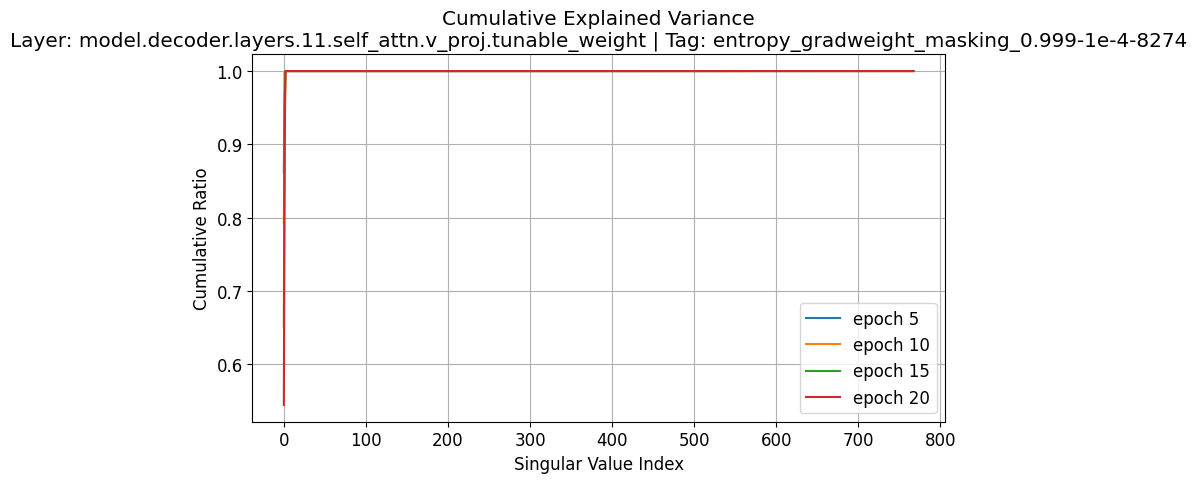

Top-10 cumulative explained variance for model.decoder.layers.11.self_attn.v_proj.tunable_weight:

Epoch 5: 1.0000
Epoch 10: 1.0000
Epoch 15: 1.0000
Epoch 20: 1.0000


In [2]:
# 예시: 분석할 실험 tag
task_name = "WIC"
tag = "entropy_gradweight_masking_0.999-1e-4-8274"

# 분석 실행
svd_results = analyze_tag(task_name, tag)

# 특정 레이어 예시
layer_name = "model.decoder.layers.11.self_attn.v_proj.tunable_weight"

# 시각화
plot_cumulative_explained_variance(svd_results, layer_name, tag)

# 실행 예시
print_topk_explained_variance(svd_results, layer_name, topk=10)

In [2]:
# functions for multiple experiments

import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

def analyze_multiple_tags(task_name, tags, base_dir='svd_weights', epochs=[5, 10, 15, 20]):
    all_results = {}
    for tag in tags:
        print(f"Analyzing tag: {tag}")
        result = analyze_tag(task_name, tag, base_dir=base_dir, epochs=epochs)
        all_results[tag] = result
    return all_results

def plot_all_methods_all_epochs(all_results_dict, layer_name, epochs=[5, 10, 15, 20], task_name=None):
    fig = plt.figure(figsize=(14, 8))
    gs = GridSpec(1, 2, width_ratios=[4, 1], figure=fig)
    ax = fig.add_subplot(gs[0])  # 그래프 영역

    plt.rcParams.update({'font.size': 14})

    color_cycle = plt.cm.tab10.colors  
    linestyle_cycle = ['solid', 'dashed', 'dashdot', 'dotted']
    alpha_cycle = [1.0, 0.8, 0.6, 0.4]

    tag_colors = {tag: color_cycle[i % len(color_cycle)] for i, tag in enumerate(all_results_dict)}

    for tag_idx, (tag, epoch_result) in enumerate(all_results_dict.items()):
        color = tag_colors[tag]
        for e_idx, epoch in enumerate(epochs):
            if epoch in epoch_result and layer_name in epoch_result[epoch]:
                _, cum_ratio = epoch_result[epoch][layer_name]
                label = f"{tag} | epoch {epoch}"
                linestyle = linestyle_cycle[e_idx % len(linestyle_cycle)]
                alpha = alpha_cycle[e_idx % len(alpha_cycle)]
                ax.plot(cum_ratio, label=label, color=color, linestyle=linestyle, alpha=alpha)

    title = f"SVD Cumulative Explained Variance\nLayer: {layer_name}"
    if task_name:
        title = f"[{task_name}] " + title
    ax.set_title(title)
    ax.set_xlabel("Singular Value Index")
    ax.set_ylabel("Cumulative Ratio")
    ax.grid(True)

    legend_ax = fig.add_subplot(gs[1])
    legend_ax.axis("off")  # 축 끄기
    handles, labels = ax.get_legend_handles_labels()
    legend_ax.legend(handles, labels, loc="upper left", fontsize=10)

    plt.tight_layout()
    plt.show()


# def plot_all_methods_all_epochs(all_results_dict, layer_name, epochs=[5, 10, 15, 20], task_name=None):
#     plt.figure(figsize=(10, 6))

#     color_cycle = plt.cm.tab10.colors  
#     linestyle_cycle = ['solid', 'dashed', 'dashdot', 'dotted']
#     alpha_cycle = [1.0, 0.8, 0.6, 0.4]

#     tag_colors = {tag: color_cycle[i % len(color_cycle)] for i, tag in enumerate(all_results_dict)}
    
#     for tag_idx, (tag, epoch_result) in enumerate(all_results_dict.items()):
#         color = tag_colors[tag]
#         for e_idx, epoch in enumerate(epochs):
#             if epoch in epoch_result and layer_name in epoch_result[epoch]:
#                 _, cum_ratio = epoch_result[epoch][layer_name]
#                 label = f"{tag} | epoch {epoch}"
#                 linestyle = linestyle_cycle[e_idx % len(linestyle_cycle)]
#                 alpha = alpha_cycle[e_idx % len(alpha_cycle)]
#                 plt.plot(cum_ratio, label=label, color=color, linestyle=linestyle, alpha=alpha)

#     title = f"SVD Cumulative Explained Variance\nLayer: {layer_name}"
#     if task_name:
#         title = f"[{task_name}] " + title
#     plt.title(title)
#     plt.xlabel("Singular Value Index")
#     plt.ylabel("Cumulative Ratio")
#     plt.grid(True)
#     plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
#     plt.tight_layout()
#     plt.show()


Analyzing tag: entropy_gradweight_masking_0.999-1e-4-8274-div2
Analyzing tag: gradient_entropy_masking_0.999-1e-4-8274
Analyzing tag: random_masking_0.999-1e-2-8274
Analyzing tag: gradient_masking_0.999-1e-5-8274
Analyzing tag: gradweight_masking_0.999-1e-5-8274


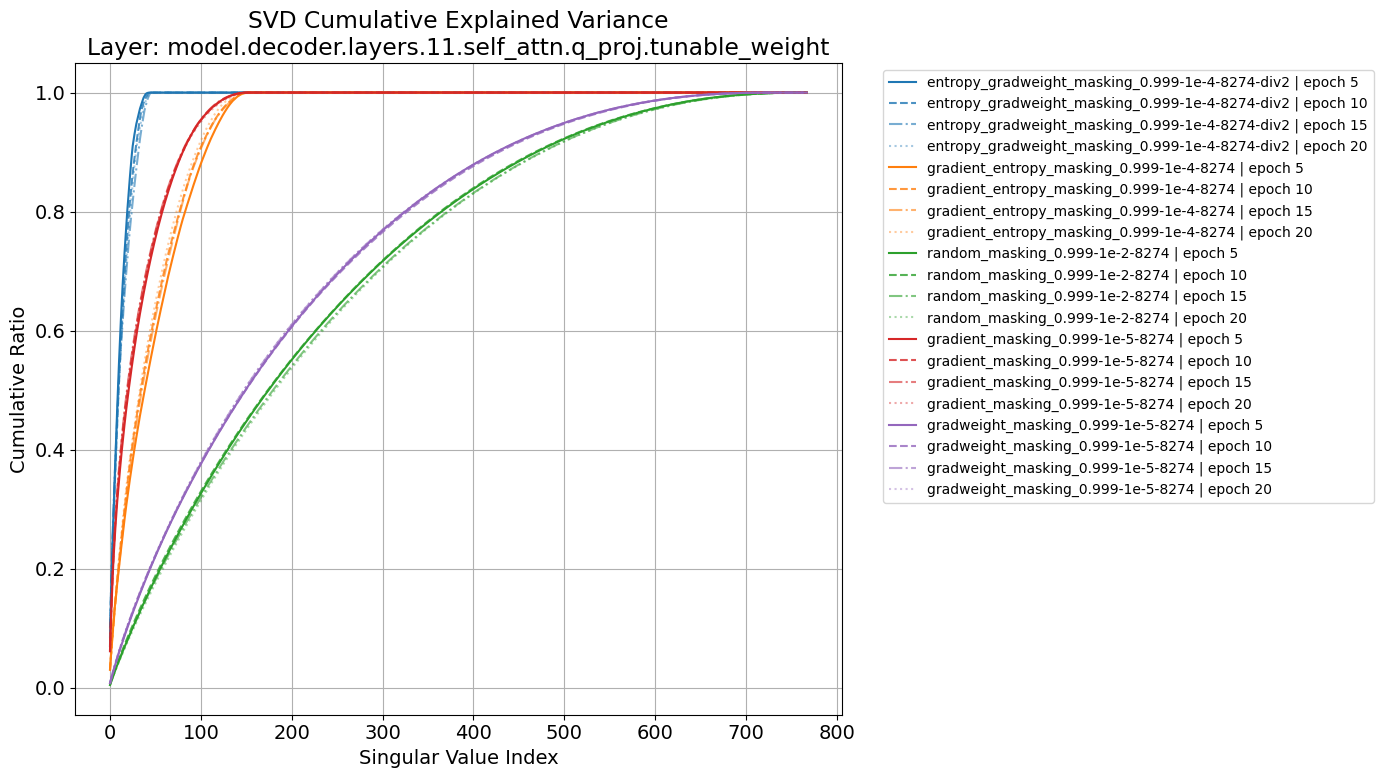

In [6]:
# layer 11, q
task_name = "WIC"
tags = [
    "entropy_gradweight_masking_0.999-1e-4-8274-div2",
    "gradient_entropy_masking_0.999-1e-4-8274",
    "random_masking_0.999-1e-2-8274",
    "gradient_masking_0.999-1e-5-8274",
    "gradweight_masking_0.999-1e-5-8274"
]

target_layer = "model.decoder.layers.11.self_attn.q_proj.tunable_weight"
epochs = [5, 10, 15, 20]

# 전체 분석
all_svd_results = analyze_multiple_tags(task_name, tags, epochs=epochs)

# 시각화
plot_all_methods_all_epochs(all_svd_results, target_layer, epochs)


Analyzing tag: entropy_gradweight_masking_0.999-1e-4-8274-div2


Analyzing tag: entropy_gradweight_masking_0.999-1e-4-8274-paramrate
Analyzing tag: gradient_entropy_masking_0.999-1e-4-8274
Analyzing tag: random_masking_0.999-1e-2-8274
Analyzing tag: gradient_masking_0.999-1e-5-8274
Analyzing tag: gradweight_masking_0.999-1e-5-8274


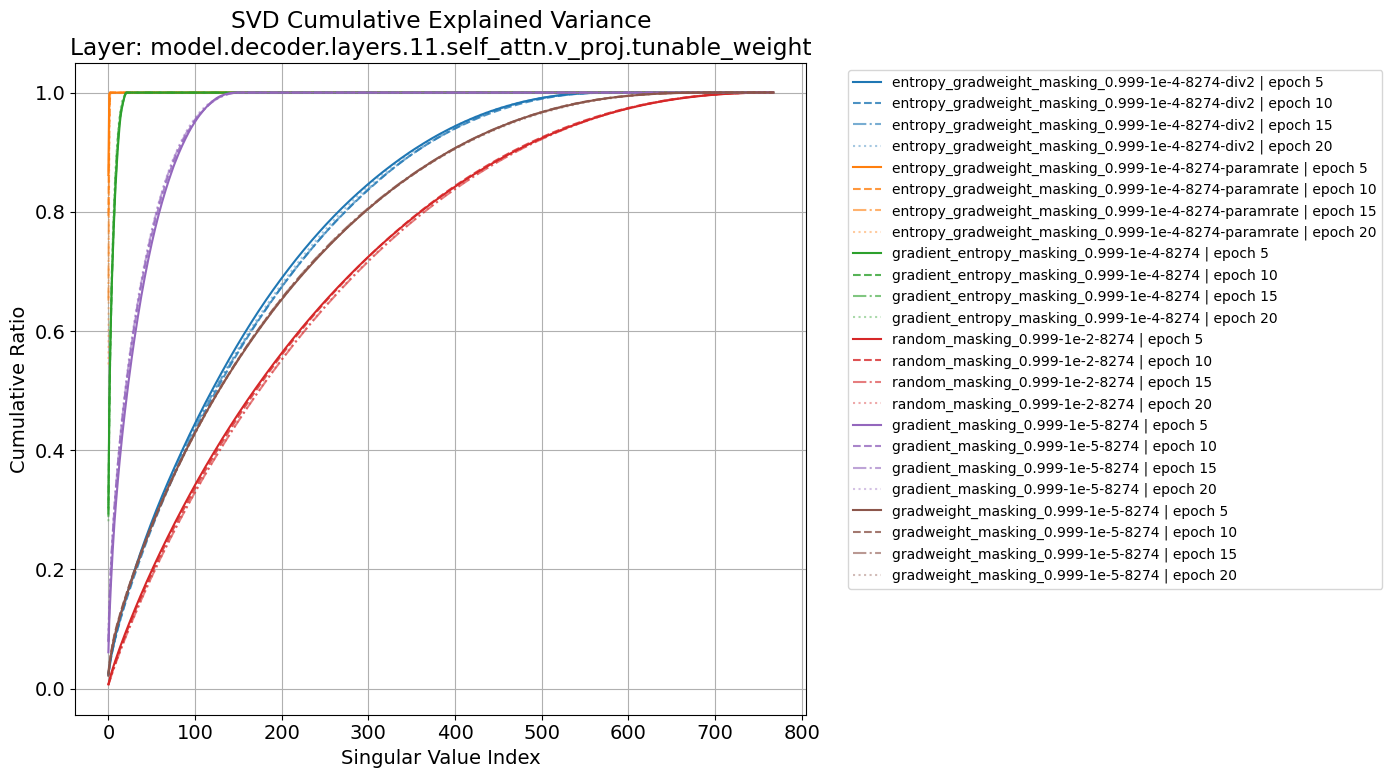

In [ ]:
# layer 11, v
task_name = "WIC"
tags = [
    "entropy_gradweight_masking_0.999-1e-4-8274-div2",
    "gradient_entropy_masking_0.999-1e-4-8274",
    "random_masking_0.999-1e-2-8274",
    "gradient_masking_0.999-1e-5-8274",
    "gradweight_masking_0.999-1e-5-8274"
]

target_layer = "model.decoder.layers.11.self_attn.v_proj.tunable_weight"
epochs = [5, 10, 15, 20]

# 전체 분석
all_svd_results = analyze_multiple_tags(task_name, tags, epochs=epochs)

# 시각화
plot_all_methods_all_epochs(all_svd_results, target_layer, epochs)


Analyzing tag: entropy_gradweight_masking_0.999-1e-4-8274
Analyzing tag: random_masking_0.999-1e-2-8274
Analyzing tag: gradient_masking_0.999-1e-5-8274
Analyzing tag: gradweight_masking_0.999-1e-5-8274


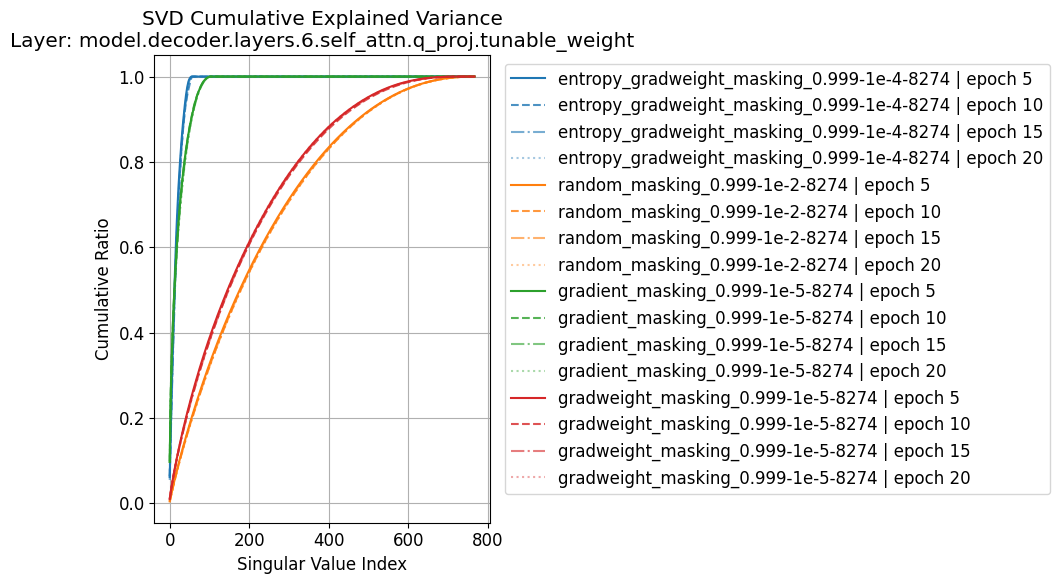

In [5]:
# layer 6, q
task_name = "WIC"
tags = [
    "entropy_gradweight_masking_0.999-1e-4-8274",
    "random_masking_0.999-1e-2-8274",
    "gradient_masking_0.999-1e-5-8274",
    "gradweight_masking_0.999-1e-5-8274"
]

target_layer = "model.decoder.layers.6.self_attn.q_proj.tunable_weight"
epochs = [5, 10, 15, 20]

# 전체 분석
all_svd_results = analyze_multiple_tags(task_name, tags, epochs=epochs)

# 시각화
plot_all_methods_all_epochs(all_svd_results, target_layer, epochs)


Analyzing tag: entropy_gradweight_masking_0.999-1e-4-8274
Analyzing tag: random_masking_0.999-1e-2-8274
Analyzing tag: gradient_masking_0.999-1e-5-8274
Analyzing tag: gradweight_masking_0.999-1e-5-8274


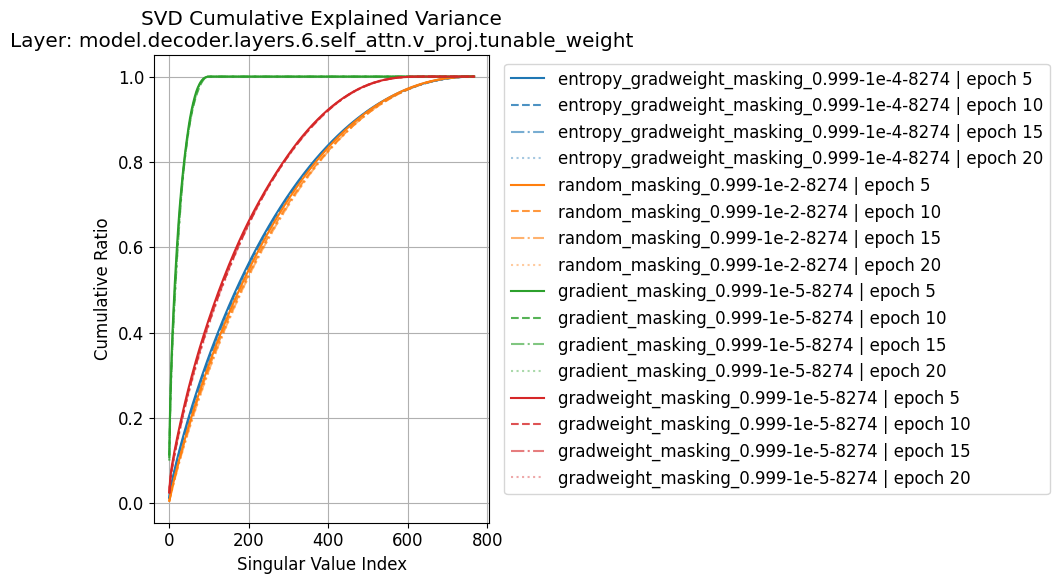

In [6]:
# layer 6, v
task_name = "WIC"
tags = [
    "entropy_gradweight_masking_0.999-1e-4-8274",
    "random_masking_0.999-1e-2-8274",
    "gradient_masking_0.999-1e-5-8274",
    "gradweight_masking_0.999-1e-5-8274"
]

target_layer = "model.decoder.layers.6.self_attn.v_proj.tunable_weight"
epochs = [5, 10, 15, 20]

# 전체 분석
all_svd_results = analyze_multiple_tags(task_name, tags, epochs=epochs)

# 시각화
plot_all_methods_all_epochs(all_svd_results, target_layer, epochs)


Analyzing tag: entropy_gradweight_masking_0.999-1e-4-8274
Analyzing tag: random_masking_0.999-1e-2-8274
Analyzing tag: gradient_masking_0.999-1e-5-8274
Analyzing tag: gradweight_masking_0.999-1e-5-8274


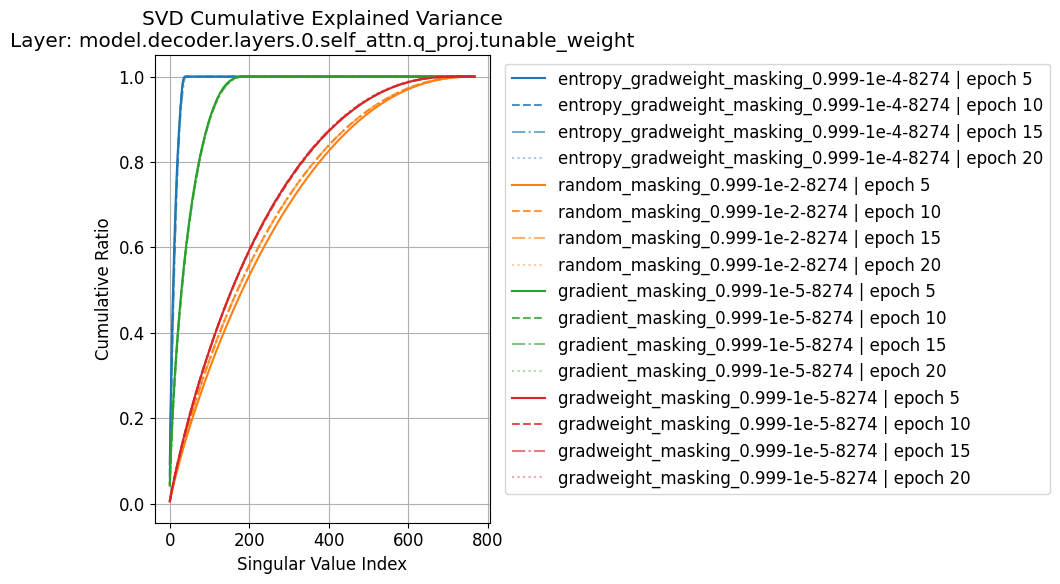

In [7]:
# layer 0, q
task_name = "WIC"
tags = [
    "entropy_gradweight_masking_0.999-1e-4-8274",
    "random_masking_0.999-1e-2-8274",
    "gradient_masking_0.999-1e-5-8274",
    "gradweight_masking_0.999-1e-5-8274"
]

target_layer = "model.decoder.layers.0.self_attn.q_proj.tunable_weight"
epochs = [5, 10, 15, 20]

# 전체 분석
all_svd_results = analyze_multiple_tags(task_name, tags, epochs=epochs)

# 시각화
plot_all_methods_all_epochs(all_svd_results, target_layer, epochs)

Analyzing tag: entropy_gradweight_masking_0.999-1e-4-8274
Analyzing tag: random_masking_0.999-1e-2-8274
Analyzing tag: gradient_masking_0.999-1e-5-8274
Analyzing tag: gradweight_masking_0.999-1e-5-8274


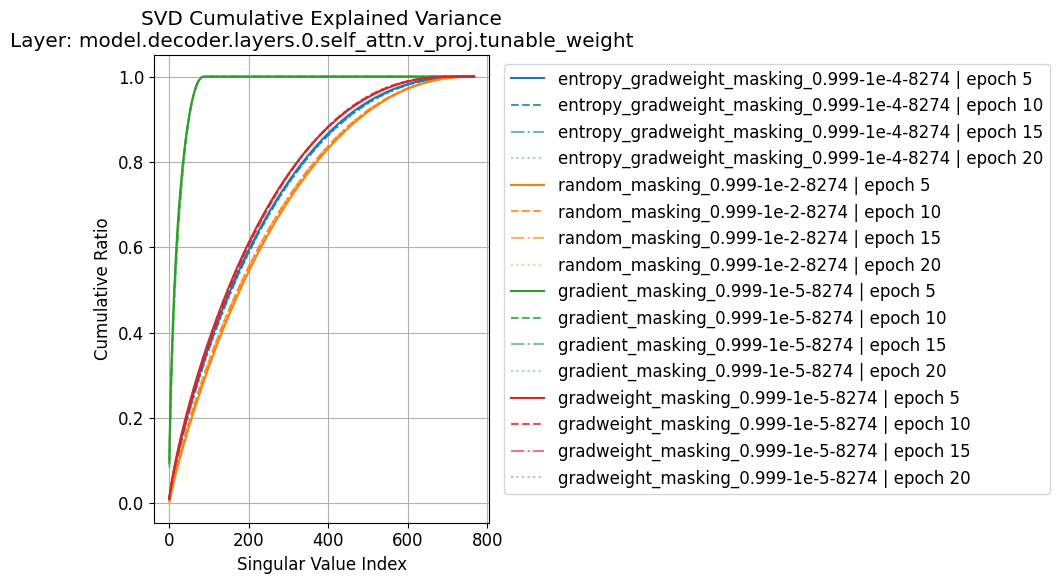

In [8]:
# layer 0, v
task_name = "WIC"
tags = [
    "entropy_gradweight_masking_0.999-1e-4-8274",
    "random_masking_0.999-1e-2-8274",
    "gradient_masking_0.999-1e-5-8274",
    "gradweight_masking_0.999-1e-5-8274"
]

target_layer = "model.decoder.layers.0.self_attn.v_proj.tunable_weight"
epochs = [5, 10, 15, 20]

# 전체 분석
all_svd_results = analyze_multiple_tags(task_name, tags, epochs=epochs)

# 시각화
plot_all_methods_all_epochs(all_svd_results, target_layer, epochs)